# Calculate 2D electric field with $dr d\Phi$

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.special import jv, kv
from scipy.special import j1 # Bessel function of the first kind of order 1, for the diffraction pattern calculation
from scipy.optimize import root_scalar
from scipy.constants import c, eta_0, mu_0, pi
import scipy.integrate as integrate

In [2]:
# jn_zeros is a function that returns the zeros of the Bessel function of the first kind, 
# which are needed to find the roots for the LP01 mode in a step-index fibre
from scipy.special import jn_zeros  # NEW: needed to get the first zero of J0

In [3]:
from scipy.optimize import brentq
from scipy.optimize import fminbound
# The Brent's method is a root-finding algorithm that combines the bisection method, the secant method, and 
# inverse quadratic interpolation. 
# https://en.wikipedia.org/wiki/Brent%27s_method
# It is designed to find roots of a continuous function within a specified interval where the function changes
#  sign. The method is efficient and robust, making it suitable for finding roots of nonlinear equations.

In [4]:
from dataclasses import dataclass

In [5]:
%pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [6]:
from joblib import Parallel, delayed
import os

In [7]:
os.cpu_count()

10

In [8]:
def cutoff(l,m):
    """
    Utility  function which returns the normalised frequency (V) at cutoff V for
    a given mode l,m. 
    
    Arguments: 
    l: Azimuthal order of the LP mode, integer >= 0
    m: Radial order of the LP mode, integer >= 1
    
    Return value: 

    Vc: Normalised frequency at cutoff for the given mode, equals to the last zero of J_{l-1} for l>=1, 
    and Vc=0 for J_{m-1} for l=0.
    
    """

    if l >= 1: 
        Vc = jn_zeros(l - 1, m)[-1]
        return Vc
    elif l == 0: 
        if m == 1: 
            Vc = 0
            return Vc
        else:
            Vc = jn_zeros(1, m - 1)[-1]
            return Vc
    else:
        raise ValueError("l must be >= 0")
    

In [9]:
def modes(V, l_max=5, m_max=5, v_margin=2e-3, az_sym_only=True): 
    """
    For each value of l, calculate the allowed values of m (if any). 

    Arguments: 
    V: Normalised frequency of the fiber, float > 0
    l_max: Maximum azimuthal order to consider, integer >= 0
    m_max: Maximum radial order to consider, integer >= 1
    v_margin: Margin for checking mode existence at cutoff, to account for numerical precision issues. 
    az_sym_only: If True, only include modes with l=0 (azimuthally symmetric modes). If False, include all modes up to l_max.
    Return value: 
    mode_list: A list of [l, m, Cv] for each mode that is supported by the fibre, where Vc is the cutoff V-number for that mode. 
    """ 
    if V <= 0: 
        raise ValueError("V must be >= 0")

    mode_list = []

    for l in range(l_max + 1): 
        if az_sym_only and l != 0: 
            continue

        for m in range(1, m_max + 1): 
            V_c = cutoff(l, m) 

            if V > V_c + v_margin: 
                mode_list.append([l, m, V_c])

            else: 
                break
    
    # A lambda function is an anonymous function in Python, which can take any number of arguments but can only have one expression. 
    # In this case, the lambda function is used as the key for sorting the mode_list. 
    mode_list.sort(key=lambda mode: mode[2])  # Sort by cutoff V-number

    return mode_list

In [10]:
def function_characteristic_eq(X, V, l): 
    """
    Function that equates to zero at the roots of the characteristic equation. 

    Arguments: 
    X: Normalised transverse propagation constant in the core, float > 0
    V: Normalised frequency of the fibre, float > 0
    Return value: 
    lhs - rhs: The difference between the left-hand side and right-hand side of the characteristic equation, which should be zero at the roots. 
    """
    # Calculate Y based on the relationship Y^2 = V^2 - X^2
    Y = np.sqrt(V**2 - X**2) # Y is the normalised transverse propagation constant in the cladding, and must be real for guided modes (X < V)

    if l > 0: 
        lhs = X * jv(l + 1, X) / jv(l, X)
        rhs = Y * kv(l + 1, Y) / kv(l, Y)
        return lhs - rhs 
    
    elif l == 0:
        lhs = X * jv(1, X) / jv(0, X)
        rhs = Y * kv(1, Y) / kv(0, Y)
        return lhs - rhs
    
    else:
        raise ValueError("l must be >= 0")

In [11]:
from scipy.optimize import brentq
import numpy as np

def find_root_XY(l, m, V, eps=np.finfo(float).eps):
    """
    Calculates the two transverse propagation constants X & Y for a given
    normalised frequency and LP mode (l,m).

    Arguments:
    V: Normalised frequency, float >= cutoff(l,m)
    l: Azimuthal order of the LP mode, integer >= 0
    m: Radial order of the LP mode, integer >= 1
    eps: Margin to avoid numerical issues near cutoff

    Returned values: 
    X_root: Normalised transverse propagation constant in the core, float > 0
    Y_root: Normalised transverse propagation constant in the cladding, float > 0
    """

    # This creates a one-variable function of X only.
    # V and l are "remembered" from the surrounding function.
    f = lambda X: function_characteristic_eq(X, V, l)

    # For all except LP01, Vc is positive. LP01 has cutoff Vc = 0.
    Vc_low = cutoff(l, m)

    if V <= Vc_low: 
        raise ValueError(f"V={V:.6f} is below cutoff for mode ({l},{m})")
    
    Vc_high = cutoff(l + 1, m) # cutoff frequency of the next azimuthal mode with the same radial order
    # We set the lower bound to be slightly above Vc_low to avoid numerical issues
    lower = Vc_low * (1 + eps)
    # Set the upper bound to be slightly below allowed upper limits to avoid numerical issues
    upper = min(Vc_high * (1 - eps), V * (1 - eps)) # between the Vc of the next mode and the maximum allowed by the fibre V
    X_root = brentq(f, lower, upper) # uses lambda function f to find the root in the specified interval
    Y_root = np.sqrt(V**2 - X_root**2)

    return X_root, Y_root

## 2D E-field of misaligned fibre

Start considering the misalignment of the E-field because we can always have a deviation in alignment between the fibre and the pupil. 

### Angular part of the LP mode field

For a weakly guiding step-index fibre, an LP mode can be written as a radial part multiplied by an angular part:

$$
E_{lm}(r,\phi) = R_{lm}(r)\,f_l(\phi),
$$

where $R_{lm}(r)$ is the radial field profile and $f_l(\phi)$ describes the angular dependence.

The angular coordinate is

$$
\phi = \mathrm{atan2}(y,x).
$$

For azimuthally symmetric modes, $l=0$, the field has no angular dependence:

$$
f_0(\phi) = 1.
$$

So for LP$_{01}$,

$$
E_{01}(r,\phi) = R_{01}(r).
$$

In this case, the value of $\phi$ does not matter physically because the mode is radially symmetric.

For asymmetric modes with $l>0$, there are two orthogonal angular forms:

$$
f_l(\phi) = \cos(l\phi),
$$

or

$$
f_l(\phi) = \sin(l\phi).
$$

Therefore,

$$
E_{lm}^{(\cos)}(r,\phi) = R_{lm}(r)\cos(l\phi),
$$

and

$$
E_{lm}^{(\sin)}(r,\phi) = R_{lm}(r)\sin(l\phi).
$$

At exactly $r=0$, the angle $\phi$ is undefined. For $l=0$ this is not a problem because $f_0(\phi)=1$. For $l>0$, the asymmetric mode field should be zero at the centre, so we set

$$
f_l(0)=0 \quad \text{for } l>0.
$$

In [12]:
def lp_mode_field_2d(x, y, a, l, X_root, Y_root, angular="cos"): 
    """
    Calculate the 2D electric field distribution of an LP mode in a step-index fibre. 

    Arguments: 
    x: 2D array of x coordinates in physical units (e.g., microns)
    y: 2D array of y coordinates in physical units (e.g., microns)
    a: Core radius of the fibre, in the same units as x and y
    l: Azimuthal order of the LP mode, integer >= 0
    X_root: Normalised transverse propagation constant in the core, float > 0
    Y_root: Normalised transverse propagation constant in the cladding, float > 0

    Return value: 
    E_2d: 2D array of the electric field distribution of the specified LP mode at the given coordinates. 
    I_2d: 2D array of the intensity distribution (|E|^2) of the specified LP mode at the given coordinates.
    """

    r = np.sqrt(x**2 + y**2) # Calculate the radial distance from the center of the fibre
    phi = np.arctan2(y, x) # Calculate the angular coordinate in the 2D grid, arctan2 is tan^-1(y/x) 
    # but takes into account the signs of x and y to determine the correct quadrant 
    rho = r / a # Normalised radial coordinate

    E_mode = np.zeros_like(r, dtype=float)

    # Calculate the field distribution based on the LP mode
    # Angular part: 
    if l ==0:
        fphi = np.ones_like(phi) # For l=0, the angular part is constant so phi=0 for cos(l*phi) 
    else:
        if angular == "cos":
            fphi = np.cos(l * phi)
        elif angular == "sin": 
            fphi = np.sin(l * phi)
        else:
            raise ValueError("angular must be 'cos' or 'sin'")
        
        # At exactly r=0, the asymmetric modes should be zero
        fphi = np.where(r > 0, fphi, 0) # np.where chooses fphi where r>0, else if r!>0 it sets fphi to 0

    # Radial masks: 
    core = r <= a # Boolean mask for core region 
    cladding = r > a # Boolean mask for cladding region

    # 
    # Author's normalization convention:
    # core: J_l(u r/a) / J_l(u)
    # cladding: K_l(w r/a) / K_l(w)
    E_mode[core] = fphi[core] * jv(l, X_root * rho[core])
    
    Constant_C = jv(l, X_root) / kv(l, Y_root) # This constant ensures the field is continuous at r=a
    E_mode[cladding] = fphi[cladding] * Constant_C * kv(l, Y_root * rho[cladding]) 

    I_mode = np.abs(E_mode)**2

    return E_mode, I_mode
    


    

In [13]:
def diffraction_limited_E_field_at_fibre_2d(x, y, lam0, F_eff, alpha=0.0, E_S=1.0, decentre=None):
    """
    Diffraction-limited telescope image electric field evaluated
    on a 2D grid at the fibre input plane.

    Parameters
    ----------
    x, y : 2D arrays
        Cartesian coordinates at the fibre input plane [m].
        The fibre centre is assumed to be at x=0, y=0.
    lam0 : float
        Wavelength [m].
    F_eff : float
        Effective focal ratio at the fibre input plane.
    alpha : float
        Central obstruction ratio.
    E_S : float
        Overall field amplitude.
    decentre : None or tuple
        If None, the image is centred on the fibre.
        If (dx, dy), the image centre is shifted by dx, dy [m]
        relative to the fibre centre.

    Returns
    -------
    E_image : 2D array
        Electric field at the fibre input plane.
    I_image : 2D array
        Intensity at the fibre input plane.
    """

    if decentre is None:
        dx, dy = 0.0, 0.0
    else:
        dx, dy = decentre

    # Coordinates relative to the centre of the image/PSF
    x_shifted = x - dx
    y_shifted = y - dy

    r_image = np.sqrt(x_shifted**2 + y_shifted**2)

    s = np.pi * r_image / (lam0 * F_eff)

    airy_term = np.divide(2 * j1(s), s,
        out=np.ones_like(s),
        where=s != 0
    )

    if alpha > 0:
        obstruction_term = np.divide(2 * j1(alpha * s), alpha * s,
            out=np.ones_like(s),
            where=(alpha * s) != 0
        )
        E_image = E_S * (airy_term - alpha**2 * obstruction_term)
    else:
        E_image = E_S * airy_term

    I_image = np.abs(E_image)**2

    return E_image, I_image

In [14]:
# np.meshgrid?

In [15]:
np.sin(0)

np.float64(0.0)

In [16]:
np.cos(0)

np.float64(1.0)

### 2D coupling efficiency as an overlap integral

The coupling efficiency between the image-plane electric field and a fibre mode is calculated from the coherent overlap integral:

$$
\eta =
\frac{
\left|\iint E_{\rm image}(x,y)\,E_{\rm mode}^{*}(x,y)\,dx\,dy\right|^2
}{
\left(\iint |E_{\rm image}(x,y)|^2\,dx\,dy\right)
\left(\iint |E_{\rm mode}(x,y)|^2\,dx\,dy\right)
}.
$$

The numerator is the squared overlap between the two electric fields:

$$
\mathrm{numerator}
=
\left|\iint E_{\rm image}(x,y)\,E_{\rm mode}^{*}(x,y)\,dx\,dy\right|^2.
$$

The denominator is the product of the total powers in each field:

$$
P_{\rm image}
=
\iint |E_{\rm image}(x,y)|^2\,dx\,dy,
$$

$$
P_{\rm mode}
=
\iint |E_{\rm mode}(x,y)|^2\,dx\,dy,
$$

so

$$
\mathrm{denominator}
=
P_{\rm image}P_{\rm mode}.
$$

Therefore,

$$
\eta =
\frac{
|\langle E_{\rm image}, E_{\rm mode}\rangle|^2
}{
P_{\rm image}P_{\rm mode}
}.
$$

The power integrals do not replace the overlap integral. They only normalise it, so that the efficiency is independent of the arbitrary amplitude scaling of either field.

For example, if

$$
E_{\rm image} \rightarrow A E_{\rm image},
$$

and

$$
E_{\rm mode} \rightarrow B E_{\rm mode},
$$

then the numerator becomes

$$
|AB^*|^2
\left|\iint E_{\rm image}E_{\rm mode}^{*}\,dx\,dy\right|^2,
$$

while the denominator becomes

$$
|A|^2 |B|^2
\left(\iint |E_{\rm image}|^2\,dx\,dy\right)
\left(\iint |E_{\rm mode}|^2\,dx\,dy\right).
$$

The scale factors cancel, so the coupling efficiency only measures how well the two field shapes match.

In the 2D Cartesian grid, the integrals are evaluated over area elements:

$$
dA = dx\,dy.
$$

So the continuous overlap integral

$$
\iint E_{\rm image}E_{\rm mode}^{*}\,dx\,dy
$$

is approximated numerically by summing/integrating over the grid.

In [ ]:
def coupling_efficiency_2d(E_image, E_mode, P_mode, x_1d, y_1d): 
    """
    Calculate the 2D coupling efficiency between an image-plane electric field
    and a fibre mode electric field.

    Input:
    E_image: 2D electric field of the image at the fibre input plane
    E_mode: 2D electric field of the fibre LP mode
    P_mode: Power of the fibre mode, this input saves computational time
    x_1d: 1D x-coordinate array used to make the 2D grid [m]
    y_1d: 1D y-coordinate array used to make the 2D grid [m]

    Output:
    eta: coupling efficiency
    numerator = |∫∫ E_image * conj(E_mode) dx dy|^2
    denominator = ∫∫ |E_image|^2 dx dy * ∫∫ |E_mode|^2 dx dy
    """

    # The integrand inside the integral
    overlap_integrand = E_image * np.conjugate(E_mode)

    # First integrate along the direction of x: 
    overlap_x = np.trapezoid(overlap_integrand, x=x_1d, axis=1)
    overlap = np.trapezoid(overlap_x, x=y_1d) 

    # Power is the integral of the electric field amplitude intensity. 
    # The power in each electric field are normalisation factors when we take the product of 
    # power in image field and power in mode field
    P_image_x = np.trapezoid(np.abs(E_image)**2, x=x_1d, axis=1)
    P_image = np.trapezoid(P_image_x, x=y_1d)
    # P_mode_x = np.trapezoid(np.abs(E_mode)**2, x=x_1d, axis=1)
    # P_mode = np.trapezoid(P_mode_x, x=y_1d)

    # Calculate the coupling efficiency
    numerator = np.abs(overlap)**2
    denominator = P_image * P_mode

    etaumerator / denominator

    return eta, numerator, denominator

In [ ]:
def single_mode_efficiency_2d(
    x, y, x_1d, y_1d,
    a, NA, lam0, F_eff, alpha,
    l, m,
    angular="cos",
    decentre=None,
    E_S=1.0
):
    """
    Calculate the 2D coupling efficiency for one LP mode.

    This is the 2D equivalent of the author's eff(l,m,...).
    """

    # Step 1 - Calculate V-number
    V = 2 * np.pi * a * NA / lam0

    # Step 2 - Find the roots for this LP mode
    X_root, Y_root = find_root_XY(l, m, V)

    # Step 3 - Calculate the 2D fibre mode field
    E_mode, I_mode = lp_mode_field_2d(
        x, y, a=a, l=l, X_root=X_root, Y_root=Y_root, angular=angular
    )
    
    # Step 3.1 - Calculate the power in the fibre mode, which is needed for the coupling efficiency calculation
    P_mode_x = np.trapezoid(I_mode, x=x_1d, axis=1)
    P_mode = np.trapezoid(P_mode_x, x=y_1d)

    # Step 4 - Calculate the 2D image field at the fibre input
    E_image, I_image = diffraction_limited_E_field_at_fibre_2d(
        x, y, lam0=lam0, F_eff=F_eff, alpha=alpha, E_S=E_S, decentre=decentre
    )


    # Step 5 - Calculate the 2D overlap efficiency
    eta, numerator, denominator = coupling_efficiency_2d(
        E_image, E_mode, P_mode, x_1d, y_1d
    )

    return eta, numerator, denominator, E_mode, I_mode, E_image, I_image

In [ ]:
def total_efficiency_2d(
    x, y, x_1d, y_1d,
    a, NA, lam0, F_eff, alpha=0.0,
    az_sym_only=False,
    decentre=None,
    E_S=1.0
):
    """
    Calculate the total 2D coupling efficiency by summing over all supported LP modes.

    If az_sym_only=True, only l=0 modes are included.
    If az_sym_only=False, l>0 modes are included with both cosine and sine branches.
    """

    # Step 1 - Calculate V-number
    V = 2 * np.pi * a * NA / lam0

    # Step 2 - Get supported mode list
    allmodes = modes(V, az_sym_only=az_sym_only)

    total_eta = 0.0
    mode_results = []

    # Step 3 - Loop over allowed modes
    for mode in allmodes:
        l, m, Vc = mode

        # l = 0 has only one angular form
        if l == 0:
            eta, numerator, denominator, E_mode, I_mode, E_image, I_image = single_mode_efficiency_2d(
                x, y, x_1d, y_1d,
                a, NA, lam0, F_eff, alpha,
                l=l, m=m,
                angular="cos",
                decentre=decentre,
                E_S=E_S
            )

            total_eta += eta

            mode_results.append({
                "l": l,
                "m": m,
                "Vc": Vc,
                "angular": "none",
                "eta": eta,
                "numerator": numerator,
                "denominator": denominator
            })

        # l > 0 has cosine and sine branches
        else:
            for angular in ["cos", "sin"]:
                eta, numerator, denominator, E_mode, I_mode, E_image, I_image = single_mode_efficiency_2d(
                    x, y, x_1d, y_1d,
                    a, NA, lam0, F_eff, alpha,
                    l=l, m=m,
                    angular=angular,
                    decentre=decentre,
                    E_S=E_S
                )

                total_eta += eta

                mode_results.append({
                    "l": l,
                    "m": m,
                    "Vc": Vc,
                    "angular": angular,
                    "eta": eta,
                    "numerator": numerator,
                    "denominator": denominator
                })

    return total_eta, mode_results

In [ ]:
def maximize_coupling_2d_fixed_radius(
    x, y, x_1d, y_1d,
    lam0, NA,
    E_mode, 
    alpha=0.0,
    decentre=None,
    E_S=1.0,
    diagnostic=False
):
    """
    Maximise 2D coupling efficiency for a fixed core radius/mode
    by optimising the effective focal ratio at the fibre input.

    E_mode is passed in because it does not change with F_eff.
    Only E_image changes during the optimisation.

    Parameters:
    x, y: 2D coordinate arrays at the fibre input plane [m]
    x_1d, y_1d: 1D coordinate arrays used to make the 2D grid [m]
    lam0: wavelength [m]
    NA: numerical aperture
    E_mode: 2D electric field of the fibre mode
    alpha: tilt angle [radians]
    decentre: lateral displacement [m]
    E_S: source electric field amplitude
    diagnostic: whether to return diagnostic information
    """

    F_eff_guess = 1 / (2 * np.tan(np.arcsin(NA)))

    lower = F_eff_guess * 0.2
    upper = F_eff_guess * 5.0

    def objective(F_eff):
        E_image, I_image = diffraction_limited_E_field_at_fibre_2d(
            x, y,
            lam0=lam0,
            F_eff=F_eff,
            alpha=alpha,
            E_S=E_S,
            decentre=decentre
        )

        eta, _, _, _, _, _, _ = single_mode_efficiency_2d()

        return 1 - eta

    F_opt = fminbound(objective, lower, upper)

    E_image_opt, I_image_opt = diffraction_limited_E_field_at_fibre_2d(
        x, y,
        lam0=lam0,
        F_eff=F_opt,
        alpha=alpha,
        E_S=E_S,
        decentre=decentre
    )

    eta_best, numerator, denominator = coupling_efficiency_2d(
        E_image_opt, E_mode, P_mode, x_1d, y_1d
    )

    if diagnostic:
        F_grid = np.linspace(lower, upper, 200)
        eta_grid = np.array([1 - objective(F) for F in F_grid])
    else:
        F_grid = None
        eta_grid = None

    return F_opt, eta_best, numerator, denominator, E_image_opt, I_image_opt, F_grid, eta_grid

In [ ]:
@dataclass
class CouplingResult2D:
    a: float
    V: float
    F_opt: float
    etat: float
    mode_results: list
    F_grid: np.ndarray
    eta_grid: np.ndarray

In [ ]:
# def sweep_core_radius_and_optimize_F_2d(
#     core_radius_range_test,
#     x, y, x_1d, y_1d,
#     lam0, NA,
#     alpha=0.0,
#     az_sym_only=False,
#     decentre=None,
#     E_S=1.0,
#     diagnostic=False
# ):
#     """
#     Loop through core radius values and optimise the effective focal ratio
#     using the 2D overlap integral.
#     """

#     results_2d = []

#     n_total = len(core_radius_range_test)
#     checkpoints = {max(1, int(np.ceil(n_total * p / 10))) for p in range(1, 11)}

#     for i, a in enumerate(core_radius_range_test, start=1):

#         V = 2 * np.pi * a * NA / lam0

#         F_opt, eta_best, mode_results, F_grid, eta_grid = maximize_coupling_2d_fixed_radius(
#             x, y, x_1d, y_1d,
#             a=a,
#             lam0=lam0,
#             NA=NA,
#             alpha=alpha,
#             az_sym_only=az_sym_only,
#             decentre=decentre,
#             E_S=E_S,
#             diagnostic=diagnostic
#         )

#         results_2d.append(
#             CouplingResult2D(
#                 a=a,
#                 V=V,
#                 F_opt=F_opt,
#                 eta_best=eta_best,
#                 mode_results=mode_results,
#                 F_grid=F_grid,
#                 eta_grid=etailon_grid
#             )
#         )

#         if i in checkpoints:
#             percent = int(round(100 * i / n_total))
#             print(f"{percent}% complete ({i}/{n_total})")

#     return results_2d

In [ ]:
def sweep_core_radius_and_optimize_F_2d(
    core_radius_range_test,
    x, y, x_1d, y_1d,
    lam0, NA,
    alpha=0.0,
    az_sym_only=False,
    decentre=None,
    E_S=1.0,
    diagnostic=False,
    n_jobs=1
):
    """
    Loop through core radius values and optimise the effective focal ratio
    using the 2D overlap integral.

    n_jobs:
        1 means normal serial loop.
        >1 means parallel processing using joblib.
    """

    n_total = len(core_radius_range_test)

    def run_one_radius(a):
        V = 2 * np.pi * a * NA / lam0

        X_root, Y_root = find_root_XY(l=0, m=1, V=V)

        E_mode, I_mode = lp_mode_field_2d(
            x, y,
            a=a,
            l=0,
            X_root=X_root,
            Y_root=Y_root,
            angular="cos"
        )

        F_opt, eta_best, mode_results, F_grid, eta_grid = maximize_coupling_2d_fixed_radius(
            x=x, y=y, x_1d=x_1d, y_1d=y_1d,
            lam0=lam0, NA=NA,
            E_mode=E_mode, P_mode=P_mode, 
            alpha=alpha,
            decentre=decentre,
            E_S=E_S,
            diagnostic=diagnostic
        )

        return CouplingResult2D(
            a=a,
            V=V,
            F_opt=F_opt,
            eta_best=eta_best,
            mode_results=mode_results,
            F_grid=F_grid,
            eta_grid=eta_grid
        )

    if n_jobs == 1:
        results_2d = []
        checkpoints = {max(1, int(np.ceil(n_total * p / 10))) for p in range(1, 11)}

        for i, a in enumerate(core_radius_range_test, start=1):
            results_2d.append(run_one_radius(a))

            if i in checkpoints:
                percent = int(round(100 * i / n_total))
                print(f"{percent}% complete ({i}/{n_total})")

    else:
        results_2d = Parallel(n_jobs=n_jobs, verbose=10)(
            delayed(run_one_radius)(a)
            for a in core_radius_range_test
        )

    return results_2d

In [39]:
r_max = 125e-6
n_grid = 1000

x_1d = np.linspace(-r_max, r_max, n_grid)
y_1d = np.linspace(-r_max, r_max, n_grid)

x, y = np.meshgrid(x_1d, y_1d)

In [40]:
core_radius_range_test = np.arange(2.5e-6, 30e-6 + 0.5e-6, 0.05e-6) # from 2 to 50 microns in meters, note arange is exclusive of the endpoint, so we add 0.5e-6 to include 30e-6 in the range
lam0 = 1.5e-6
NA = 0.1
print(f"Testing {len(core_radius_range_test)} core radius values from {core_radius_range_test[0]*1e6:.2f} to {core_radius_range_test[-1]*1e6:.2f} microns")

Testing 560 core radius values from 2.50 to 30.45 microns


In [41]:
# results_2d_sym = sweep_core_radius_and_optimize_F_2d(
#     core_radius_range_test,
#     x, y, x_1d, y_1d,
#     lam0=lam0,
#     NA=NA,
#     alpha=0.0,
#     az_sym_only=True,
#     decentre=None,
#     E_S=1.0
# )

In [42]:
results_2d = sweep_core_radius_and_optimize_F_2d(
    core_radius_range_test,
    x, y, x_1d, y_1d,
    lam0, NA,
    alpha=0.0,
    az_sym_only=True,
    decentre=None,
    E_S=1.0,
    diagnostic=False,
    n_jobs=4
)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


TypeError: coupling_efficiency_2d() missing 1 required positional argument: 'y_1d'

In [ ]:
results_2d_sym

[CouplingResult2D(a=np.float64(5e-06), V=np.float64(2.0943951023931957), F_opt=np.float64(5.768997175007332), eta_best=np.float64(0.7816780285256221), mode_results=[{'l': 0, 'm': 1, 'Vc': 0, 'angular': 'none', 'eta': np.float64(0.7816780285256221), 'numerator': np.float64(4.144960325979994e-21), 'denominator': np.float64(5.302644023138395e-21)}], F_grid=array([ 0.99498744,  1.11498592,  1.23498441,  1.35498289,  1.47498138,
         1.59497986,  1.71497835,  1.83497683,  1.95497532,  2.0749738 ,
         2.19497229,  2.31497077,  2.43496926,  2.55496774,  2.67496623,
         2.79496471,  2.9149632 ,  3.03496168,  3.15496016,  3.27495865,
         3.39495713,  3.51495562,  3.6349541 ,  3.75495259,  3.87495107,
         3.99494956,  4.11494804,  4.23494653,  4.35494501,  4.4749435 ,
         4.59494198,  4.71494047,  4.83493895,  4.95493744,  5.07493592,
         5.19493441,  5.31493289,  5.43493138,  5.55492986,  5.67492835,
         5.79492683,  5.91492532,  6.0349238 ,  6.15492229,  

In [ ]:
eta_best_values = [result.eta_best for result in results_2d_sym]

ValueError: x and y must be the same size

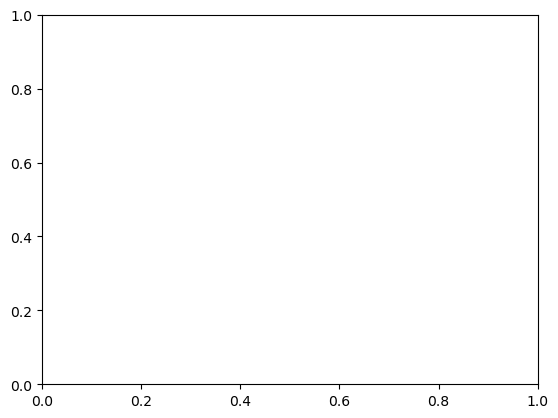

In [ ]:
plt.scatter(core_radius_range_test, eta_best_values, marker='o')

In [ ]:
# results_2d_off_ax = sweep_core_radius_and_optimize_F_2d(
#     core_radius_range_test,
#     x, y, x_1d, y_1d,
#     lam0=lam0,
#     NA=NA,
#     alpha=0.0,
#     az_sym_only=False,
#     decentre=(1e-6, 0.0),
#     E_S=1.0
# )


KeyboardInterrupt: 

In [ ]:
def eta_psf_vs_decentre_2d(
    prepared_modes,
    x, y, x_1d, y_1d,
    lam0,
    F_eff,
    alpha,
    decentre_array,
    E_S=1.0,
    direction_angle=0.0
):
    """
    Calculate point-source coupling efficiency as a function of image decentre.

    prepared_modes:
        precomputed fibre modes for one core radius

    decentre_array:
        array of image offsets at the fibre input plane [m]

    direction_angle:
        direction of the offset in the x-y plane.
        For a circularly symmetric system, this should not matter.
    """

    eta_psf = []
    mode_results_all = []

    for d in decentre_array:
        dx = d * np.cos(direction_angle)
        dy = d * np.sin(direction_angle)

        eta_total, mode_results = total_eff_2d_prepared(
            prepared_modes,
            x, y, x_1d, y_1d,
            lam0=lam0,
            F_eff=F_eff,
            alpha=alpha,
            decentre=(dx, dy),
            E_S=E_S
        )

        eta_psf.append(eta_total)
        mode_results_all.append(mode_results)

    eta_psf = np.array(eta_psf)

    return eta_psf, mode_results_all

In [ ]:
def background_efficiency_for_one_radius_2d(
    a,
    x, y, x_1d, y_1d,
    NA, lam0,
    alpha=0.0,
    az_sym=True,
    mode_case="smf",
    decentre_max=None,
    n_decentre=50,
    E_S=1.0,
    n_F_grid=60
):
    """
    For one core radius:
        1. prepare fibre modes
        2. optimise F_eff for centred point source
        3. calculate eta_psf(d)
        4. integrate eta_psf(d) to get flat-background efficiency
    """

    V = 2 * np.pi * a * NA / lam0

    prepared_modes = prepare_modes_2d(
        x, y,
        a=a,
        NA=NA,
        lam0=lam0,
        az_sym=az_sym,
        mode_case=mode_case
    )

    # Optimise F for centred point source only
    F_opt, eta_center, mode_results_center, E_image_opt, I_image_opt = (
        maximize_coupling_fix_a_prepared(
            prepared_modes,
            x, y, x_1d, y_1d,
            lam0=lam0,
            NA=NA,
            alpha=alpha,
            decentre=None,
            E_S=E_S,
            n_F_grid=n_F_grid
        )
    )

    # Choose decentre range if not supplied
    if decentre_max is None:
        airy_radius = 1.22 * lam0 * F_opt
        decentre_max = 5 * max(a, airy_radius)

    decentre_array = np.linspace(0, decentre_max, n_decentre)

    # Calculate eta_psf(d) using fixed F_opt
    eta_psf, mode_results_decentre = eta_psf_vs_decentre_2d(
        prepared_modes,
        x, y, x_1d, y_1d,
        lam0=lam0,
        F_eff=F_opt,
        alpha=alpha,
        decentre_array=decentre_array,
        E_S=E_S
    )

    # Integrate over the flat background
    eta_background = eta_background_from_eta_psf(
        decentre_array,
        eta_psf
    )

    return {
        "a": a,
        "V": V,
        "F_opt": F_opt,
        "eta_center": eta_center,
        "eta_background": eta_background,
        "decentre_array": decentre_array,
        "eta_psf": eta_psf,
        "mode_results_center": mode_results_center,
        "mode_results_decentre": mode_results_decentre,
        "E_image_opt": E_image_opt,
        "I_image_opt": I_image_opt
    }

In [ ]:
def eta_background_from_eta_psf(decentre_array, eta_psf):
    """
    Calculate the coupling efficiency for a flat uniform extended background.

    This assumes the background is circularly symmetric and uniform.
    """

    numerator = np.trapezoid(
        eta_psf * 2 * np.pi * decentre_array,
        x=decentre_array
    )

    denominator = np.pi * decentre_array[-1]**2

    eta_background = numerator / denominator

    return eta_background

In [ ]:
def background_efficiency_vs_core_2d(
    core_radius_array,
    x, y, x_1d, y_1d,
    NA, lam0,
    alpha=0.0,
    az_sym=True,
    mode_case="smf",
    decentre_max=None,
    n_decentre=50,
    E_S=1.0,
    n_F_grid=60
):
    """
    Sweep over core radius and calculate:
        - centred point-source efficiency
        - optimal F_eff
        - eta_psf(d)
        - flat-background efficiency
    """

    results = []

    n_total = len(core_radius_array)
    checkpoints = {max(1, int(np.ceil(n_total * p / 10))) for p in range(1, 11)}

    for i, a in enumerate(core_radius_array, start=1):

        row = background_efficiency_for_one_radius_2d(
            a=a,
            x=x,
            y=y,
            x_1d=x_1d,
            y_1d=y_1d,
            NA=NA,
            lam0=lam0,
            alpha=alpha,
            az_sym=az_sym,
            mode_case=mode_case,
            decentre_max=decentre_max,
            n_decentre=n_decentre,
            E_S=E_S,
            n_F_grid=n_F_grid
        )

        results.append(row)

        if i in checkpoints:
            percent = int(round(100 * i / n_total))
            print(f"{percent}% complete ({i}/{n_total})")

    return results